<a href="https://colab.research.google.com/github/carcablop/Python_Cursos/blob/main/Notebooks/Sesion_5_CatalogoCSV.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎙️ Python Schools 2026 — Sesión 5
## Catálogo CSV- Crear, leer y escribir archivos CSV usando Pandas
### Oriente Stereo · Agua Blanca · Cali

## ¿Dónde estamos en el proyecto?

En la sesión anterior estuvimos trabajando con la libreria Pathlib y construimos la función que nos escanear las rutas del sistema de archivos de la radio. Esta función encuentra todos los archivos de audio y retorna los datos listos para el catalago en formato CSV.

| **S5** | **📂 Catálogo CSV con `pandas` + columnas completas** | ⬅️ Hoy |




## 🎯 Objetivo de esta sesión

Hoy construimos el **catálogo central** del sistema: un archivo `catalogo_oriente.csv` que:

1. **Registra todos los programas**
2. **Guarda el nombre original Y el nombre normalizado** de cada archivo mp3 o mp4 que encontró con la función desarrollada en la sesión anterior.
3. **Captura metadatos reales** del archivo: tamaño, fecha, tipo, ruta
4. **Marca si tiene backup** o no (columna clave para S7)
5. Está diseñado para ser leído por la CLI o consola de comandos.

### **¿Qué es un archivo CSV?**:

Es un archivo de texto que guarda datos en formato de tabla.

**CSV = Comma-Separated Values** → "Valores separados por comas"

Es como una hoja de cálculo guardada como texto plano. Cada línea es una fila, las columnas se separan con comas.

Ejemplo:
```
nombre_programa,conductor,nombre_archivo_original
CronicasOriente,Fernanda Ríos,CronicasOriente_2025-11-10_Fernanda.mp3
NoticiasOriente,Carlos Mena,
DebatesDelBarrio,Sin definir,
```





### **¿Qué es Pandas?**
https://pandas.pydata.org/
https://pandas.pydata.org/docs/getting_started/overview.html


**Pandas** es la librería más usada en Python para trabajar con datos tabulares (como tablas de Excel). Esta libreria, de codigo abierto, va a permitir manipular, limpiar, y analizar datos tabulares.

Principales estructuras de datos de Pandas:

**Dataframe** : Tabla de datos bidimensional, es decir, donde cada columna contiene los valores de una variable y cada fila contiene un conjunto de valores de cada columna.

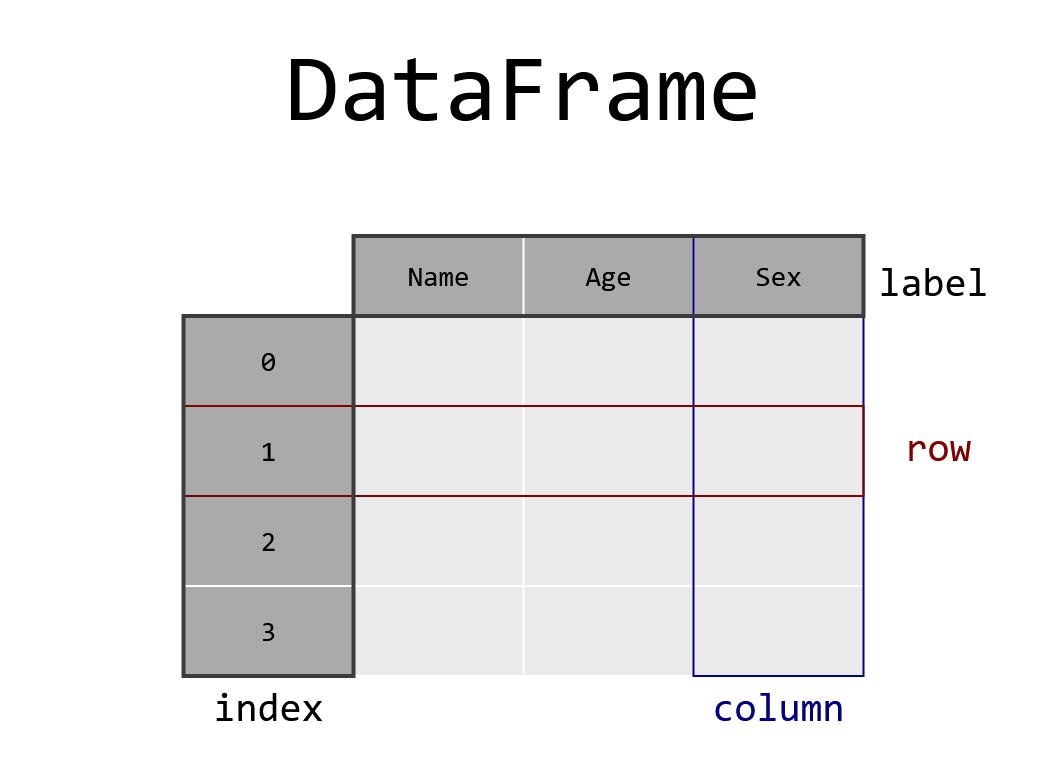

| Concepto | ¿Qué es? | Ejemplo |
|----------|---------|---------|
| `DataFrame` | Una tabla completa con filas y columnas | Todo el catálogo |
| `Series` | Una sola columna del DataFrame | Lista de conductores |
| `pd.read_csv()` | Leer un CSV y convertirlo en DataFrame | Abrir el catálogo |
| `df.to_csv()` | Guardar un DataFrame como CSV | Guardar el catálogo |
| `df[columna]` | Acceder a una columna | `df['conductor']` |
| `df.loc[fila]` | Acceder a una fila por su índice | `df.loc[0]` |

---



###**Empezar a usar Pandas**
Para cargar el paquete de Pandas y empezar a trabajar con él debemos importarlo.
La comunidad de Pandas, acordo como alias de Pandas como `pd`

```
import pandas as pd
```

###**Creando un DataFrame con Pandas desde cero:**


#### **El esquema completo del catálogo**

Estas son **todas las columnas** que tendrá nuestro `catalogo_oriente.csv`:

| Columna | Obligatorio | Descripción |
|---------|------------|-------------|
| `id_archivo` | ✅ Sí | Identificador único del archivo |
| `nombre_programa` | ✅ Sí | Nombre del programa en la parrilla |
| `conductor` | ✅ Sí | Nombre del conductor del programa |
| `nombre_archivo_original` | ✅ Sí | Nombre del archivo tal como está guardado, sin cambios |
| `nombre_archivo_normalizado` | ✅ Sí | Nombre convertido al estándar PROGRAMA_AAAA-MM-DD_CONDUCTOR_DESCRI_EPIS.ext |
| `tipo_archivo` | ✅ Sí | Extensión del audio: `.mp3`, `.mp4` |
| `tamaño_mb` | ✅ Sí | Tamaño del archivo en megabytes MB |
| `ruta_sistema` | ✅ Sí | Ruta completa al archivo en el sistema de la emisora |
| `fecha_modificacion_archvio` | ✅ Sí | Fecha de última modificación del archivo |
| `fecha de backup` | ✅ Sí | Fecha de backup |
| `tiene_backup` | ✅ Sí | `True` o `False` — ¿ya está respaldado? |

> Las columnas "Son obligatorias", pero si desconocemos del nobmre del conductor o de la fecha del archivo, se debe poner como desconocido. Eso es correcto y esperado.


### ✏️ Ejercicio Guiado 1: Crear un DataFrame desde cero

Queremos almacenar los datos de la radio de Oriente estereo en una tabla, ya conocemos los nombres de los programas, quien los conduce y los nombres de los archivos mp3, como tambien las rutas del sistema de esos archivos.

Podemos crear una tabla de datos Dataframe a partir de un diccionario, donde las claves son los nombres de las columnas y los valores son las filas.



```
DataFrame(data=diccionario, index=filas, columns=columnas, dtype=tipos)
```



In [ ]:
import pandas as pd

#diccionario de datos, donde la clave es el nombre del
datos = {
     "id_programa": [
        "001",
        "002",
        "003"
    ],

    "nombre_programa": [
        "EN LA RAYA",
        "ENTRE NOSOTROS",
        "SONGOROCOSONGO"
    ],
    "conductor": [
        "Fernanda Ríos",
        "Carlos Mena",
        "Desconocido"
    ],
    "nombre_archivo_original": [
        "EN LA RAYA DEPORTES 03 DE DIC DE 2025.mp3",
        "PAGANO BOLERO - boleros existenciales.mp3",
        "EN_LA_RAYA_2025-08-25.mp4"
    ],
    "nombre_archivo_normalizado": [
        "EN_LA_RAYA_2025-12-03.mp3",
        "PAGANO_BOLERO_sin_fecha.mp3",
        "EN_LA_RAYA_2025-08-25.mp4"
    ],
    "tipo_archivo": [
        ".mp3",
        ".mp3",
        ".mp4"
    ],
    "tamaño_mb": [
        28.4,
        30,              # ← None en números: pandas lo convierte a NaN
        29.5
    ],
    "ruta_sistema": [
        "DISCO/PROGRAMAS/EN LA RAYA/EN LA RAYA DEPORTES 03 DE DIC DE 2025.mp3",
        "DISCO/PROGRAMAS/PAGANO BOLERO/PAGANO BOLERO - boleros existenciales.mp3",
        "DISCO/PROGRAMAS/EN LA RAYA/EN_LA_RAYA_2025-08-25.mp4"
    ],
    "fecha_modificacion": [
        "2025-11-10 14:32:00",
        "2025-11-10 14:32:00",
        "2025-11-10 14:32:00"
    ],
    "tiene_backup": [
        False,
        False,
        False
    ],
     "fecha_backup":[
         None,
         None,
         None
     ]
}

df = pd.DataFrame(datos)

df

,ruta_sistema
0,DISCO/PROGRAMAS/EN LA RAYA/EN LA RAYA DEPORTES...
1,DISCO/PROGRAMAS/PAGANO BOLERO/PAGANO BOLERO - ...
2,DISCO/PROGRAMAS/EN LA RAYA/EN_LA_RAYA_2025-08-...


In [ ]:
#Veamos como se ve
print("📋 CATÁLOGO INICIAL — ORIENTE STEREO")
print(f"   {len(df)} programas registrados | {len(df.columns)} columnas")
df

#### Creación de un DataFrame a partir de una lista de diccionarios

In [ ]:
import pandas as pd
df = pd.DataFrame(
    [{"n_programa": "EN LA RAYA", "n_archivo": "EN LA RAYA DEPORTES 2025.mp3", "conductor" : "Oriente estero"},
     {"n_programa": "DEJAME SER ARTE", "n_archivo": "DEJAME SER ARTE 03-07-25.mp3", "conductor" : "desconocido"},
     {"n_programa": "A PRENDER LA ONDA", "n_archivo": "Episodio 125.mp3", "conductor" : "Oriente estero"}]
)
df

,n_programa,n_archivo,conductor
0,EN LA RAYA,EN LA RAYA DEPORTES 2025.mp3,Oriente estero
1,DEJAME SER ARTE,DEJAME SER ARTE 03-07-25.mp3,desconocido
2,A PRENDER LA ONDA,Episodio 125.mp3,Oriente estero


#### Atributos de un Dataframe

Existen varias propiedades o métodos para ver las características de un DataFrame.

| Propiedades/metodos | ¿Qué es? |
|----------|---------|
| `DataFrame` | Una tabla completa con filas y columnas |
| `df.info()` | Devuelve información (número de filas, número de columnas, índices, tipo de las columnas y memoria usado) sobre el DataFrame df |
|`df.shape` | Devuelve una tupla con el número de filas y columnas del DataFrame df|
|`df.size` |Devuelve el número de elementos del DataFrame.|
|`df.columns`| Devuelve una lista con los nombres de las columnas del DataFrame df.|
|`df.index `| Devuelve una lista con los nombres de las filas del DataFrame df|
|`df.dtypes`| Devuelve una serie con los tipos de datos de las columnas del DataFrame df|
|`df.head(n)`| Devuelve las n primeras filas del DataFrame df|
|`df.tail(n) `| Devuelve las n últimas filas del DataFrame df|


In [ ]:
#Prueba los métodos y propiedades anteriores


In [ ]:
#imprime la informacion del dataframe
df.info()

In [ ]:
#imprime el tamño y columnas del dataframe.


### **¿Cómo accedemos a los elementos de un Dataframe?**
#### **Acceder a una columna especifica**

> Agregar bloque entrecomillado



Podemos acceder a los elementos de un dataframe por el nombre de la columna o nombre de la fila. Muy parecido a la forma de acceder a un valor con la clave en un diccionario.

Para seleccionar una sola columna, utilice corchetes [] seguidos del nombre de la columna de interés.

```
nombre_dataframe["nombre de la columna"]
```

```
nombre_dataframe.nombre_de_la_columna  
```

In [ ]:
#devuelve toda la columa "n_programa". Obtengo los nombres de los programas de la radio.
df['n_programa']

,n_programa
0,EN LA RAYA
1,DEJAME SER ARTE
2,A PRENDER LA ONDA


In [ ]:
#Devuelve una serie con los elementos de la columna de nombre columna del DataFrame df.
df.n_programa

,n_programa
0,EN LA RAYA
1,DEJAME SER ARTE
2,A PRENDER LA ONDA


Cada **columna** de un **DataFrame** es una **Serie**. Al seleccionar una sola columna, el objeto devuelto es una **Serie de panda**s. Podemos verificar esto comprobando el tipo de salida:


In [ ]:
type(df["n_programa"])

#### **Seleccionar varias columnas**:

Estamos interesados en seleccionar dos columnas, puede ser el nombre del archivo y el nombre del programa.

Para seleccionar varias columnas, utilice una lista de nombres de columnas dentro de los corchetes de selección` []`.

*Nota*

> Los corchetes interiores definen una lista de Python con nombres de columnas, mientras que los corchetes exteriores se utilizan para seleccionar los datos de un DataFrame de pandas:





In [ ]:
programa_archivo = df[["n_programa","n_archivo"]]
programa_archivo

#### **Acceder a unas filas especificas**

**Ejemplo**: Estamos interesados en los archivos cuyo conductor sea oriente estereo

Para seleccionar filas en función de una expresión condicional, utilice una condición dentro de los corchetes de selección `[ ].`



```
df[df['conductor'] == "Oriente estero"]
```



La condición dentro de los corchetes de selección `df['conductor'] == "Oriente estero"` comprueba en qué filas la columna Conductor tiene un valor igual a oriente estereo:

In [ ]:
#filtra por filas:

Tambien podemos usar la funcion condicional **isin()**, si queremos agregar a nuestra condicion una más, por ejemplo, quiero los programas cuyos conductores son Oriente estereo y cesar pagano.

la función **`.isin()`** se le pasa como parametro una lista.


In [ ]:
df[df['conductor'].isin(["Oriente estero","cesar pagano"])]

### Acceder a especificas columnas y filas de un Dataframe
#### Acceder mediante posiciones. Usamos `.iloc()`

```
#Devuelve el elemento que se encuentra en la fila i y la columna j del DataFrame df:

df.iloc[i, j]
```






In [ ]:
df.iloc[:1,:3]

,n_programa,n_archivo,conductor
0,EN LA RAYA,EN LA RAYA DEPORTES 2025.mp3,Oriente estero


#### Acceder mediante nombres de la fila  y de la columna. Usamos `iloc()`


```
#Devuelve el elemento que se encuentra en la fila con nombre fila y la columna de con nombre columna del DataFrame df.

df.loc[fila, columna]
```



In [ ]:
#Devuelve un dataframe donde
cond_programa= df.loc[df["conductor"] == "Oriente estero", ["n_programa", "n_archivo"]]
cond_programa

###Añadir nuevas columnas a un Dataframe

Añadir nuevas columnas es similar cuando añadir un nuevo par a un diccionario. Pero con dataframes pasamos como valor una lista o una Serie.


```python
# Añade al DataFrame df una nueva columna con el nombre nombre y los valores de la lista lista. La lista debe tener el mismo tamaño que el número de filas de df.
df[nombre] = lista
```
```python
# Añade al DataFrame df una nueva columna con el nombre nombre y los valores de la serie serie. Si el tamaño de la serie es menor que el número de filas de df se rellena con valores NaN mientras que si es mayor se recorta.

d[nombre] = serie
```






In [ ]:
import pandas as pd
df['tamaño_mb'] = pd.Series([30, 29.5, 80])
print(df)

          n_programa                     n_archivo       conductor  tamaño_mb
0         EN LA RAYA  EN LA RAYA DEPORTES 2025.mp3  Oriente estero       30.0
1    DEJAME SER ARTE  DEJAME SER ARTE 03-07-25.mp3     desconocido       29.5
2  A PRENDER LA ONDA              Episodio 125.mp3  Oriente estero       80.0


In [ ]:
#Agregar una nueva columna al dataframe anterior. Fecha de modificación de archivo.


####Convertir una columna al tipo **`datetime`**
A menudo una columna contiene cadenas que representan fechas. Para convertir estas cadenas al tipo datetime se utiliza el siguiente método:

`pd.to_datetime(columna, formato)`



In [ ]:
df['fecha_modificacion'] = pd.Series(["3-1-2025"])
print(df)
print(pd.to_datetime(df.fecha_modificacion,format = '%d-%m-%Y'))

          n_programa                     n_archivo       conductor  tamaño_mb  \
0         EN LA RAYA  EN LA RAYA DEPORTES 2025.mp3  Oriente estero       30.0   
1    DEJAME SER ARTE  DEJAME SER ARTE 03-07-25.mp3     desconocido       29.5   
2  A PRENDER LA ONDA              Episodio 125.mp3  Oriente estero       80.0   

  fecha_modificacion  
0           3-1-2025  
1                NaN  
2                NaN  
0   2025-01-03
1          NaT
2          NaT
Name: fecha_modificacion, dtype: datetime64[ns]


###Concatenacion de DataFrame

Cuando queremos agregar nuevas filas a un DataFrame, en versiones actuales de pandas se recomienda usar

`pd.concat().`

Este método permite unir o concatenar dos o más DataFrames, ya sea agregando filas o columnas. En este caso, lo usamos para añadir una nueva fila convirtiéndola primero en un DataFrame y luego uniéndola con el original.

De forma simple, el proceso es:

*  Crear un DataFrame con la nueva fila.
*  Usar pd.concat() para unirlo con el DataFrame original.
*  Utilizar ignore_index=True para reorganizar los índices automáticamente.




Así se conserva la estructura de los datos y se mantiene compatibilidad con las versiones más recientes de pandas.


In [ ]:
nueva_fila = pd.DataFrame([{
    'n_programa': 'DIANA URIBE',
    'n_archivo': 'La historia de la radio y la radio en la historia.mp3',
    'conductor': 'Diana Uribe',
    'tamaño_m': 50
}])

df = pd.concat([df, nueva_fila], ignore_index=True)
df

,n_programa,n_archivo,conductor,tamaño_mb,fecha_modificacion,tamaño_m
0,EN LA RAYA,EN LA RAYA DEPORTES 2025.mp3,Oriente estero,30.0,3-1-2025,NaN
1,DEJAME SER ARTE,DEJAME SER ARTE 03-07-25.mp3,desconocido,29.5,NaN,NaN
2,A PRENDER LA ONDA,Episodio 125.mp3,Oriente estero,80.0,NaN,NaN
3,DIANA URIBE,La historia de la radio y la radio en la histo...,Diana Uribe,NaN,NaN,50.0


####Eliminar una filade un dataframe
Usando el metodo drop() y pasandole el indice de la fila.



```
df.drop(indice).reset_index(drop=True)
```




### ¿Cómo escribir un DataFrame de Pandas en un archivo?
Cuando terminamos de manipular datos en Pandas, podemos exportar el dataframe a otro format como CSV.
Usando el metodo

`.to_csv("archivo.csv")`.

Para utilizar una codificación de caracteres específica, puedes utilizar el argumento encoding:


```python
import pandas as pd
df.to_csv('myDataFrame.csv', sep=',', encoding='utf-8')
```


> [Documentacion oficial](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.to_csv.html)




Para escribir un archivo **CSV** en una carpeta nueva o en una carpeta anidada, primero Necesita crearlo usando **Pathlib**.

In [ ]:
from pathlib import Path
filepath = Path("folder/subfolder/out.csv")
filepath.parent.mkdir(parents=True, exist_ok=True)
df.to_csv(filepath)

### Leer datos de un archivo CSV

Pandas proporciona la función: **`.read_csv('out.csv')`**, para leer los datos desde un archivo CSV.

In [ ]:
import pandas as pd
data_frame= pd.read_csv("folder/subfolder/out.csv")
data_frame.info()

### Manipulando los datos textuales.
Usamos los metodos de cadena de pandas.
Esos metodos estan disponibles utilizando el `str`


```python
data_frame["n_programa"].str.lower()
```

```python
data_frame["n_archivo"].str.split(",")
```

```python
data_frame["n_archivo"].str.contains(".mp3")
```



```python
#ver el nombre mas largo
data_frame["n_archivo"].str.len()
```



Ejemplos

Aplica los metodos anteriores

In [ ]:
#Vamos a obtener el nombre de archivo mas largo del Dataframe.
#usamos el operador loc para filtrar por el indice de la fila que contiene el nombre mas grande y le pasamo sel nobmre de la columna.
data_frame.loc[data_frame["n_archivo"].str.len().idxmax(), 'n_archivo']

### ✏️ Ejercicios:

La función que vamos a contruir hoy hará parte del modulo **`catalogo.py`** del mvp para la radio Oriente estereo.

Tendremos como resultado el **`catalogo_oriente.csv`**, con la estructura del dataFrame que se menciono al inicio de este Notebook

1. Cargaremos las funciones de la sesion 4 para simular los archivos de la radio y para escanear los archivos para catalogar.



In [ ]:
#cargar la simulacion construida en s4

carpetas = [
    "/content/disco_prueba/PROGRAMAS/BARRIO ADENTRO",
    "/content/disco_prueba/PROGRAMAS/EN LA RAYA",
    "/content/disco_prueba/PROGRAMAS/DEJAME SER ARTE/PROGRAMAS",
    "/content/disco_prueba/PROGRAMAS/DEJAME SER ARTE/MUSICA",
    "/content/disco_prueba/PROGRAMAS/DEJAME SER ARTE/PRODUCCION DSA",
    "/content/disco_prueba/PROGRAMAS/A PRENDER LA ONDA",
    "/content/disco_prueba/PROGRAMAS/CESAR PAGANO",
    "/content/disco_prueba/PROGRAMAS/DIANA URIBE",
]

archivos_prueba = [
    "/content/disco_prueba/PROGRAMAS/BARRIO ADENTRO/BARRIO ADENTRO 06-06-25.mp3",
    "/content/disco_prueba/PROGRAMAS/BARRIO ADENTRO/BARRIO ADENTRO 17-07-25.mp3",
    "/content/disco_prueba/PROGRAMAS/EN LA RAYA/EN LA RAYA DEPORTES- AGOSTO 25 DE 2025.mp3",
    "/content/disco_prueba/PROGRAMAS/EN LA RAYA/EN LA RAYA DEPORTES DIC 1 DE 2025.mp3",
    "/content/disco_prueba/PROGRAMAS/EN LA RAYA/En la Raya Deportes- Septiembre 29 de 2025.mp3",
    "/content/disco_prueba/PROGRAMAS/DEJAME SER ARTE/PROGRAMAS/DEJAME SER ARTE 03-07-25.mp3",
    "/content/disco_prueba/PROGRAMAS/DEJAME SER ARTE/PROGRAMAS/DSA 02-10-25.mp3",
    "/content/disco_prueba/PROGRAMAS/DEJAME SER ARTE/MUSICA/Arcangel - Andan Diciendo.mp3",
    "/content/disco_prueba/PROGRAMAS/DEJAME SER ARTE/MUSICA/GAMBOA - Fuiste Tu.mp3",
    "/content/disco_prueba/PROGRAMAS/DEJAME SER ARTE/PRODUCCION DSA/CABEZOTE DSA.mp3",
    "/content/disco_prueba/PROGRAMAS/DEJAME SER ARTE/PRODUCCION DSA/PISADOR DSA 1.mp3",
    "/content/disco_prueba/PROGRAMAS/DEJAME SER ARTE/PRODUCCION DSA/SEPARADOR DSA 3 FINAL.mp3",
    "/content/disco_prueba/PROGRAMAS/DEJAME SER ARTE/FONDO DSA.jpg",
    "/content/disco_prueba/PROGRAMAS/DEJAME SER ARTE/FONDO DSA",
    "/content/disco_prueba/PROGRAMAS/A PRENDER LA ONDA/Episodio 35 2025.mp3",
    "/content/disco_prueba/PROGRAMAS/A PRENDER LA ONDA/Episodio 118.mp3",
    "/content/disco_prueba/PROGRAMAS/A PRENDER LA ONDA/Episodio 122 2023 (1).mp3",
    "/content/disco_prueba/PROGRAMAS/A PRENDER LA ONDA/Episodio 290 2025.mp3",
    "/content/disco_prueba/PROGRAMAS/CESAR PAGANO/SONGOROCOSONGO/SONGORO - leonor gonzalez mina la negra grande colombia.mp3",
    "/content/disco_prueba/PROGRAMAS/CESAR PAGANO/PAGANO BOLERO/PAGANO BOLERO - mujeres bolero parte 2.mp3",
    "/content/disco_prueba/PROGRAMAS/CESAR PAGANO/PAGANO BOLERO/PAGANO BOLERO - boleros inspirados estaciones dima.mp3",
    "/content/disco_prueba/PROGRAMAS/DIANA URIBE/1 - La historia de la radio y la radio en la historia.mp3",
    "/content/disco_prueba/PROGRAMAS/DIANA URIBE/7 - Comienzos de la radio en Colombia.mp3",
    "/content/disco_prueba/PROGRAMAS/DIANA URIBE/13 - Radio educativa, Radio Sutatenza.mp3",
]

CARPETAS_EXCLUIDAS= ["MUSICA", "PRODUCCION", "PRODUC", "PRODUCCION DSA", "PRODUCCION DSA", "ARCHIVOS AUDIO", "VISUALES"]

CARPETAS_PROGRAMAS = {
    "BARRIO ADENTRO":       "barrio_adentro",
    "EN LA RAYA":           "en_la_raya_deportes",
    "DEJAME SER ARTE":      "dejame_ser_arte",
    "ENTRE NOSOTROS":       "entre_nosotros",
    "A PRENDER LA ONDA":    "a_prender_la_onda",
    "PAGANO BOLERO":        "pagano_bolero",
    "SONGOROCOSONGO":       "songorocosongo",
    "DIANA URIBE":          "diana_uribe",
    "FRECUENCIA UMBRELLA":  "frecuencia_umbrella",
    "LATINOAMERICA TIERRA": "latinoamerica_tierra",
}
CONDUCTORES = ["CESAR PAGANO"]

In [ ]:
from pathlib import Path

def escaner(ruta_programas :  str):
  ruta_programas = Path(ruta_programas)

  for archivo in ruta_programas.rglob("*.mp3"):

    ruta_relativa = archivo.relative_to(ruta_programas)

    directorio_padre= ruta_relativa.parent.name
    if directorio_padre in CARPETAS_EXCLUIDAS:
      continue
    elif directorio_padre in CARPETAS_PROGRAMAS:
      print(f"{directorio_padre}: {archivo} :directorio_padre")
    elif directorio_padre in CONDUCTORES:
      if ruta_relativa.parent.parent.name == "":
        print(f"No hay mas rutas, {directorio_padre} es un conductor, y ese archivo no tiene programa asociado")
      else:
        if ruta_relativa.parent.parent.name in CARPETAS_PROGRAMAS:
          print("es un programa")
      print(directorio_padre)
      print(f"es un conductor:{directorio_padre}")
    else:
      print(f"no encontro el programa del archivo:{ruta_relativa} ")
ruta = "/content/disco_prueba/PROGRAMAS"
escaner(ruta)


2. Construir escaner: Iterar los archivos de la radio encontrando los que sean .mp3 y .**mp4**
